In [6]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import sys

from scripts.contrast_functions import get_contrasts_from_img, create_histogram_plots
from scripts.annotation_class import watershed_annotator

## Setting some constants

| Parameter             | Description                                                                                                                                    |
| --------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| `IMAGE_DIRECTORY`     | The directory path of the saved images; the images need to be in `.jpg`, `.png` , or `.tif` format.                                                       |
| `MASK_SAVE_DIRECTORY` | The directory path where the semantic masks are saved. A new folder will be created if a folder does not already exist.                                                       |
| `CREATE_NEW_MASK`            | If the masks are already created or not, if you want to annotate images to create new masks and save the results to `MASK_SAVE_DIRECTORY` toggle this to `TRUE`. |
| `USE_SINGLE_MASK`            | If you would like to use the same mask for each image, toggle this to `TRUE`. Only use the same mask if each image was taken with the flakes of interest in EXACTLY the same location. If images were taken at different times, create a seperate mask for each individual image and toggle this to `FALSE`. |                                                         |
| `SAVE_RESULTS `      | Additionally, if you would like to automatically save the output graph images, toggle this to `TRUE`.                                |
| `RESULTS_DIRECTORY`          | If `SAVE_RESULTS` is `TRUE`, then this is the location the graphs will be saved. A new folder will be created if one does not already exist.                                                                                                      |


`TIP`: Take images with the flake(s) of interest near the center of the image to avoid possible data contamination from vignetting.


In [7]:
IMAGE_DIRECTORY = r"../Datasets/GMMDetectorDatasets/contrast_tests/substrate_thickness/images"
MASK_SAVE_DIRECTORY = r"../Datasets/GMMDetectorDatasets/contrast_tests/substrate_thickness/masks"

CREATE_NEW_MASK = True
USE_SINGLE_MASK = False

SAVE_RESULTS = False
RESULTS_DIRECTORY = r"../Datasets/GMMDetectorDatasets/Color_Temperature/results"

## Checking if the given Parameters are valid


In [8]:
assert os.path.exists(IMAGE_DIRECTORY), "Flake directory does not exist"

os.makedirs(MASK_SAVE_DIRECTORY, exist_ok=True)

## Creating masks

The annotator uses the watershed algorithm to discern the foreground from the background.  
It is only necessary to define these two classes as the thickness is inferred later by the clustering.

A red outline is shown between the background and foreground indicating the mask boundry.

The Masks are saved with the same file type as the images in the `MASK_SAVE_DIRECTORY` Folder with the same name as the image.

### Controls

|            Keys             | Description                                                  |
| :-------------------------: | ------------------------------------------------------------ |
| <kbd>A</kbd> / <kbd>D</kbd> | Previous / Next Image                                        |
|        <kbd>S</kbd>         | Save the current annotion, very important after every image! |
|        <kbd>C</kbd>         | Delete the current annotations                               |
|    <kbd>Left MBT </kbd>     | Set a marker for foreground                                  |
|    <kbd>Right MBT </kbd>    | Set a marker for background                                  |
|       <kbd>ESC</kbd>        | Exit the program                                             |


In [9]:
if CREATE_NEW_MASK:
    annotator = watershed_annotator(
        image_directory=IMAGE_DIRECTORY,
        mask_directory=MASK_SAVE_DIRECTORY,
    )
    annotator.run()

## Calculate contrast graphs
This is where the magic happens. By default, the histograms will fit two gaussian components to the data with 100 bins in the histograms. These parameters can be adjusted in the function call if desired.

Note: There is a possibility that some channels will not have distinct gaussians. This will produce this a convergence warning. Just ignore it, the code will still work as expected.

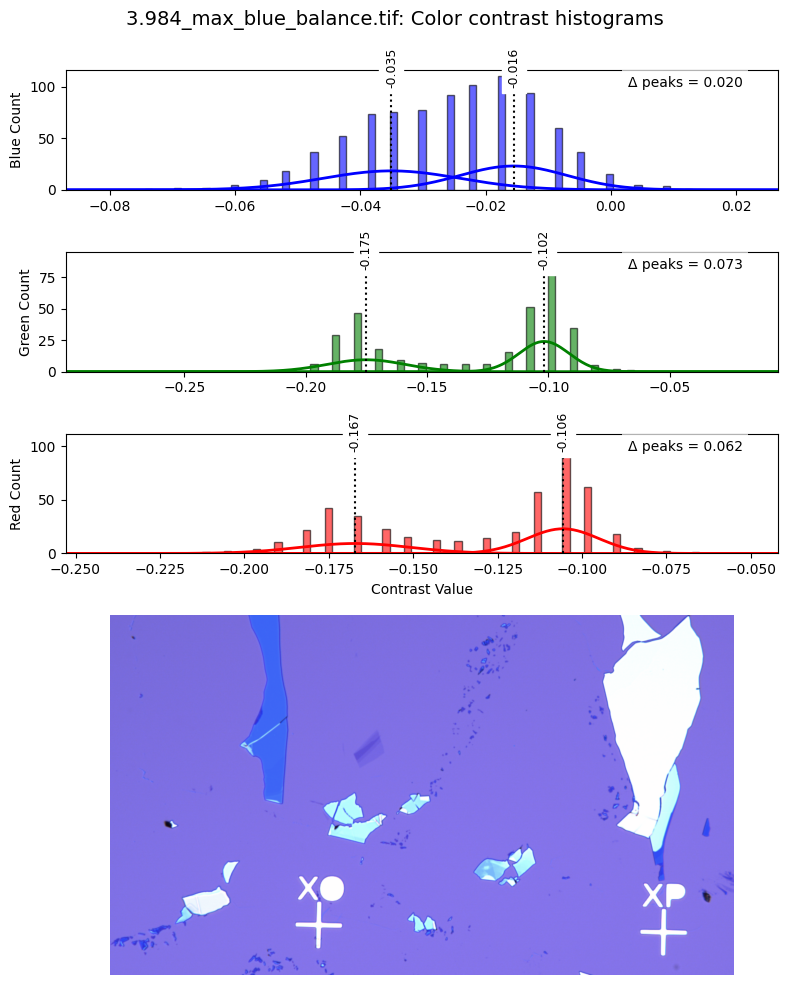

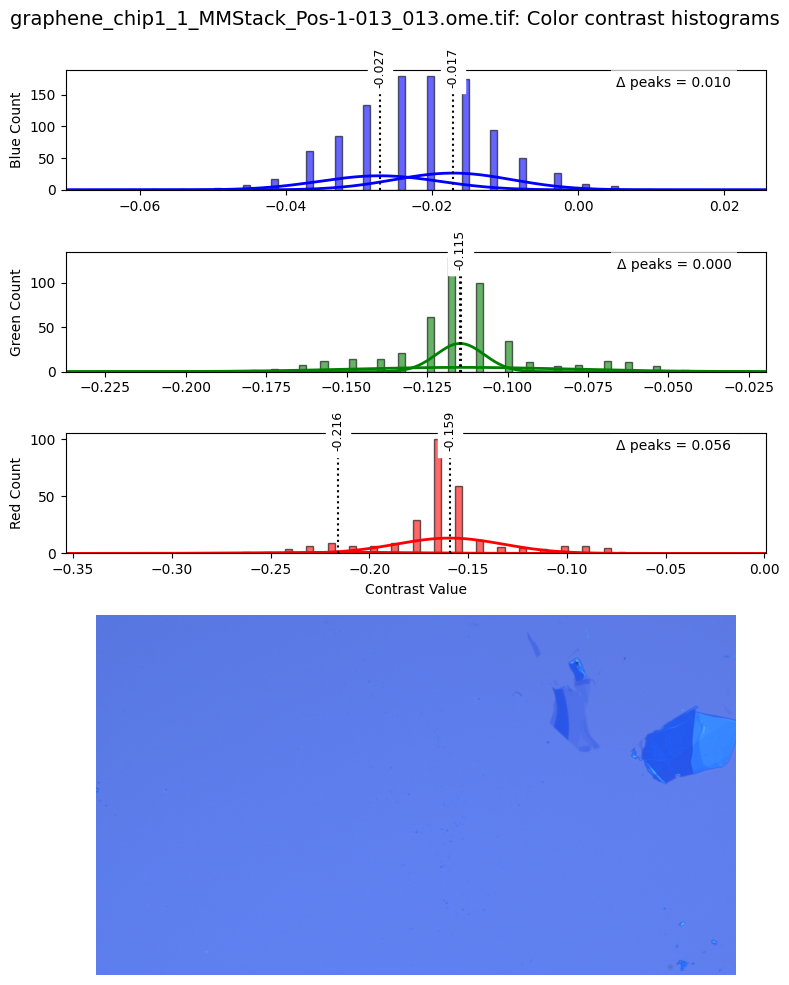

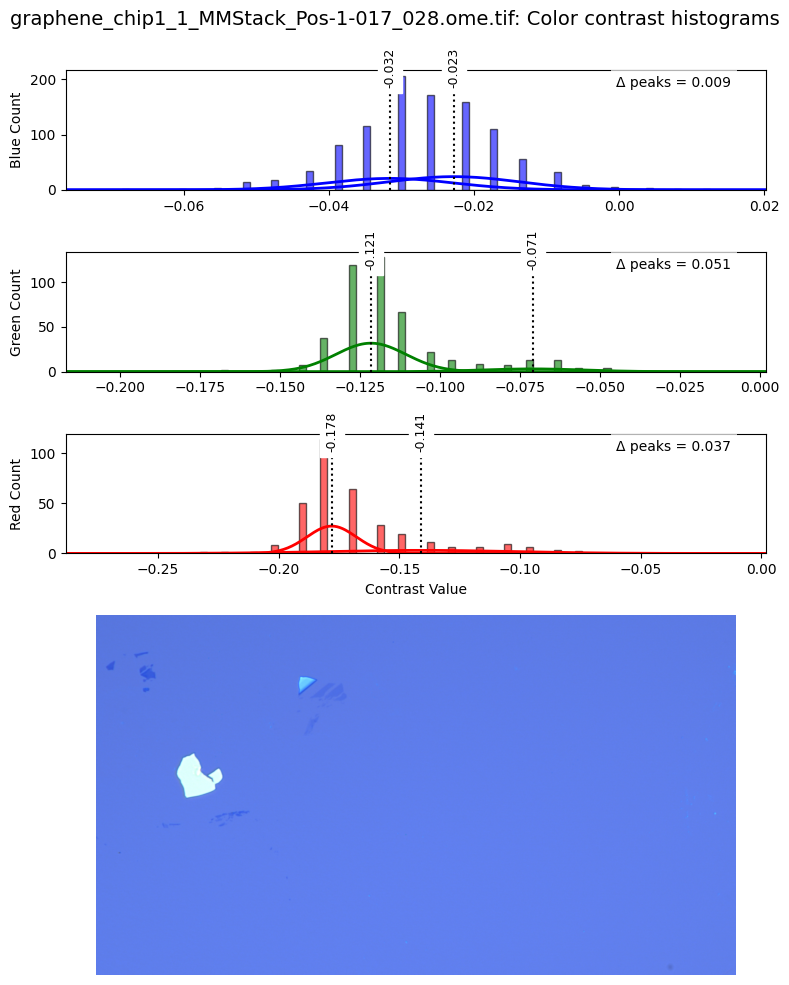

In [10]:
# Gets the mask files from the directory
mask_files = os.listdir(MASK_SAVE_DIRECTORY)
if not mask_files:
    print("No mask files found in the specified directory.")
    sys.exit(1)

# Gets the image files from the directory
image_files = os.listdir(IMAGE_DIRECTORY)
if not image_files:
    print("No image files found in the specified directory.")
    sys.exit(1)

# This will be the dict where each image path is saved with its datapoints contrast data
contrast_dict = {}

# If you want to use the same mask for all images, then the first mask in the dir is used
if USE_SINGLE_MASK:
    mask_name = mask_files[0]
    mask_path = os.path.join(MASK_SAVE_DIRECTORY, mask_name)
    print(f"Using mask: {mask_name}")

    for img in image_files:
        img_path = os.path.join(IMAGE_DIRECTORY, img)
        datapoints_contrast = get_contrasts_from_img(
            image_path=img_path,
            mask_path=mask_path,
        )
        contrast_dict[img_path] = datapoints_contrast

else:
    for mask_name in mask_files:
        # Find the corresponding image
        image_path = os.path.join(IMAGE_DIRECTORY, mask_name)
        if not os.path.exists(image_path):
            image_path = os.path.join(
                IMAGE_DIRECTORY, mask_name.replace(".png", ".jpg", ".tif")
            )
        if not os.path.exists(image_path):
            print(f"Could not find image corresponding to mask '{mask_name}', skipping")
            continue

        mask_path = os.path.join(MASK_SAVE_DIRECTORY, mask_name)

        datapoints_contrast = get_contrasts_from_img(
            image_path=image_path,
            mask_path=mask_path,
        )
        contrast_dict[image_path] = datapoints_contrast

# Show plots
create_histogram_plots(contrast_dict, save_results=SAVE_RESULTS, results_dir=RESULTS_DIRECTORY)
# Example call to adjust the number of bins or number of gaussian components:
# create_histogram_plots(contrast_dict, save_results=SAVE_RESULTS, results_dir=RESULTS_DIRECTORY, bins=200, num_components=3)

